# PowerPrompt: The AI Energy & Water Dilemma

An end-to-end **pandas + NumPy + visualization** project on one of the
defining technology dilemmas of 2025-2026: **AI capability is growing
faster than the electricity grids and water systems that physically
support it.**

### The dilemma, in one sentence

Every gain in AI capability — bigger models, more users, more inference —
draws on real electricity and real water, in real places, on real grids
that take years to expand; there is no way to get the benefits of
AI-at-scale without *someone* bearing the resource cost, and the two main
ways to reduce one cost (water or energy) tend to increase the other.

### Grounding this in real, recent numbers

- Global data center electricity consumption reached about **415 TWh in
  2024** and grew **17% year-over-year to roughly 485 TWh in 2025**, with
  **AI-focused data centers growing even faster — about 50% in just 2025
  alone** (IEA, *Key Questions on Energy and AI*, 2026).
- The IEA's Base Case projects global data center electricity demand will
  roughly **double to about 945 TWh by 2030** — growing about **15% per
  year, more than four times faster** than electricity demand from every
  other sector combined (IEA, *Energy and AI*, 2025).
- AI workloads were roughly **15-20% of total data center power demand in
  2024**, a share various analysts project could reach **35-50% by 2030**
  (IEA; ScienceDirect, 2025).
- In the U.S., data centers could account for **6.7% to 12.0% of total
  national electricity consumption by 2028** — but the strain is far more
  concentrated in specific places: data centers already consume roughly
  **21% of Ireland's national electricity** (potentially 32% by 2026) and
  **26% of Virginia's state electricity** (Environmental Law Institute,
  2026; AIMultiple, 2026).
- The five largest U.S. hyperscalers (Amazon, Alphabet, Meta, Microsoft,
  Oracle) are projected to spend about **$725 billion on AI infrastructure
  in 2026** — a **77% increase** over the roughly **$410 billion** they
  spent in 2025 (Financial Times earnings-guidance compilation, via
  Axis Intelligence, 2026).
- On the water side, a 2026 policy analysis frames the core engineering
  tension directly: **evaporative cooling uses more water but less
  electricity; air cooling uses more electricity but conserves water** —
  there is no cooling approach that minimizes both at once with current
  technology (MOST Policy Initiative, Apr 2026). Some hyperscalers are
  responding: Microsoft's newer closed-loop, zero-evaporation facilities
  each avoid **over 125 million liters of water per year** versus older
  evaporative designs, while Google has pledged to **replenish 120% of the
  water it consumes by 2030** (IEA, *Energy and AI*, 2025).

> **What's real vs. synthetic in this notebook:** every specific figure in
> the bullets above is a **real, cited estimate**. The **year-by-year
> monthly trajectories, the country/state breakdown table, the
> cooling-technology trade-off curve, and the individual facility-level
> data are synthetic** — built to be **directionally and quantitatively
> consistent with the real anchor figures above**, so we can do full
> hands-on time-series, matrix, and trade-off analysis without needing a
> live subscription to IEA/EPRI/LBNL's underlying models.

### What this notebook covers
1. Real reference data: the numbers above, as small structured tables
2. Calibrating a synthetic 2020-2030 electricity-demand trajectory
3. NumPy: component breakdown, water-footprint ufuncs, regional grid-strain masks
4. The core dilemma: the energy-water cooling trade-off curve
5. pandas: regional/country time series, hyperscaler capex, `groupby` and pivoting
6. Visualization: annotated trajectories, stacked components, geographic strain map
7. A one-page dashboard
8. Wrap-up: what the data does and doesn't settle


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data

Small tables reproduced directly from the cited sources.


In [2]:
# ---------------------------------------------------------------
# REAL DATA: global data center electricity demand, key anchor years
# Source: IEA, "Key Questions on Energy and AI" (2026) and "Energy and AI" (2025)
# ---------------------------------------------------------------
real_global_demand_anchors = pd.DataFrame({
    "year": [2024, 2025, 2030],
    "global_dc_electricity_twh": [415, 485, 945],
    "note": ["IEA base figure", "+17% YoY (IEA)", "IEA Base Case projection"],
})
real_global_demand_anchors


,year,global_dc_electricity_twh,note
0,2024,415,IEA base figure
1,2025,485,+17% YoY (IEA)
2,2030,945,IEA Base Case projection


In [3]:
# ---------------------------------------------------------------
# REAL DATA: AI's share of total data center power demand over time
# Source: IEA (2025); ScienceDirect (2025) synthesis of multiple estimates
# ---------------------------------------------------------------
real_ai_share_anchors = pd.DataFrame({
    "year": [2024, 2030],
    "ai_share_of_dc_power_pct_low": [15, 35],
    "ai_share_of_dc_power_pct_high": [20, 50],
})
real_ai_share_anchors


,year,ai_share_of_dc_power_pct_low,ai_share_of_dc_power_pct_high
0,2024,15,20
1,2030,35,50


In [4]:
# ---------------------------------------------------------------
# REAL DATA: regional/local grid strain examples -- illustrating that the
# NATIONAL average (a few percent) hides much more concentrated local strain
# Source: Environmental Law Institute (2026); AIMultiple (2026)
# ---------------------------------------------------------------
real_regional_strain = pd.DataFrame({
    "region": ["Ireland (national)", "Virginia, USA (state)", "United States (national, 2028E)"],
    "data_center_share_of_electricity_pct": [21, 26, 9.4],   # US 2028 figure is the midpoint of the cited 6.7-12.0% range
    "note": ["potentially 32% by 2026", "as of recent reporting", "midpoint of cited 6.7-12.0% range"],
})
real_regional_strain


,region,data_center_share_of_electricity_pct,note
0,Ireland (national),21.0,potentially 32% by 2026
1,"Virginia, USA (state)",26.0,as of recent reporting
2,"United States (national, 2028E)",9.4,midpoint of cited 6.7-12.0% range


In [5]:
# ---------------------------------------------------------------
# REAL DATA: hyperscaler AI infrastructure capital expenditure
# Source: Financial Times earnings-guidance compilation, via Axis Intelligence (2026)
# ---------------------------------------------------------------
real_hyperscaler_capex = pd.DataFrame({
    "year": [2025, 2026],
    "big_five_ai_capex_usd_bn": [410, 725],
})
real_hyperscaler_capex["yoy_growth_pct"] = real_hyperscaler_capex["big_five_ai_capex_usd_bn"].pct_change() * 100
real_hyperscaler_capex


,year,big_five_ai_capex_usd_bn,yoy_growth_pct
0,2025,410,NaN
1,2026,725,76.829268


In [6]:
# ---------------------------------------------------------------
# REAL DATA: data center electricity consumption BY COMPONENT
# Source: IEA, "Energy and AI" (2025)
# ---------------------------------------------------------------
real_component_breakdown = pd.DataFrame({
    "component": ["Servers", "Storage systems", "Networking equipment", "Cooling (efficient hyperscale)", "Cooling (less-efficient enterprise)"],
    "share_of_electricity_pct": [60, 5, 5, 7, 30],
    "note": ["~60% typical", "~5%", "up to 5%", "efficient hyperscale low end", "less-efficient enterprise high end"],
})
real_component_breakdown


,component,share_of_electricity_pct,note
0,Servers,60,~60% typical
1,Storage systems,5,~5%
2,Networking equipment,5,up to 5%
3,Cooling (efficient hyperscale),7,efficient hyperscale low end
4,Cooling (less-efficient enterprise),30,less-efficient enterprise high end


## 2. Building the calibrated synthetic datasets


In [7]:
# ---------------------------------------------------------------
# A) MONTHLY GLOBAL ELECTRICITY-DEMAND TRAJECTORY, 2020-2030, split into
#    "AI-attributable" vs. "non-AI" data center load. Calibrated so the
#    ANNUAL totals hit the real 2024/2025/2030 anchors from Section 1,
#    with AI's SHARE rising from ~15% (2024) toward ~45% (2030, middle of
#    the cited 35-50% range) along a smooth S-curve.
# ---------------------------------------------------------------
months = pd.period_range("2020-01", "2030-12", freq="M").to_timestamp()
n_m = len(months)
year_frac = (months.year - 2020) + (months.month - 1) / 12

# Piecewise-smooth annual growth curve anchored EXACTLY at the three real
# data points (2024: 415, 2025: 485, 2030: 945 TWh), interpolated with a
# monotonic cubic-like ease between anchors and extrapolated backward to 2020
# Piecewise-smooth annual growth curve anchored EXACTLY at the three real
# data points (2024: 415, 2025: 485, 2030: 945 TWh), interpolated with a
# monotonic ease between anchors. Anchors are placed at MID-YEAR (year+0.5)
# since the real annual figures represent that year's average, not its
# January 1 value -- placing them at Jan 1 would bias each year's average
# upward as the trend keeps climbing through the year.
anchor_years = np.array([2020.5, 2022.5, 2024.5, 2025.5, 2030.5])
anchor_totals = np.array([260, 340, 415, 485, 945])   # 2020/2022 are illustrative backward extension
annual_total_twh = np.interp(months.year + (months.month - 1) / 12, anchor_years, anchor_totals)
annual_total_twh += rng.normal(0, 3, n_m)   # small monthly noise

# AI share: logistic rise from ~8% (2020, negligible) through the real
# 15-20% (2024) anchor toward ~45% (2030)
t = (months.year + (months.month - 1) / 12 - 2024)
ai_share = 0.17 / (1 + np.exp(-1.1 * t)) + 0.15 / (1 + np.exp(-0.6 * (t - 3)))
ai_share = np.clip(ai_share, 0.06, 0.48)

demand = pd.DataFrame({
    "month": months,
    "total_dc_electricity_twh_annualized": annual_total_twh,
    "ai_share": ai_share,
})
demand["ai_dc_electricity_twh_annualized"] = demand["total_dc_electricity_twh_annualized"] * demand["ai_share"]
demand["non_ai_dc_electricity_twh_annualized"] = demand["total_dc_electricity_twh_annualized"] - demand["ai_dc_electricity_twh_annualized"]

# Validate against the real anchors
check = demand.set_index(demand["month"].dt.year).groupby(level=0)["total_dc_electricity_twh_annualized"].mean()
print("Calibration check (annual mean, should be close to 415 / 485 / 945):")
print(check.loc[[2024, 2025, 2030]].round(0))
demand.head()


Calibration check (annual mean, should be close to 415 / 485 / 945):
month
2024    419.0
2025    482.0
2030    932.0
Name: total_dc_electricity_twh_annualized, dtype: float64


,month,total_dc_electricity_twh_annualized,ai_share,ai_dc_electricity_twh_annualized,non_ai_dc_electricity_twh_annualized
0,2020-01-01,257.620633,0.06,15.457238,242.163395
1,2020-02-01,260.721714,0.06,15.643303,245.078411
2,2020-03-01,254.311021,0.06,15.258661,239.052360
3,2020-04-01,264.187315,0.06,15.851239,248.336076
4,2020-05-01,261.914884,0.06,15.714893,246.199991


In [8]:
# ---------------------------------------------------------------
# B) COUNTRY/STATE-LEVEL ELECTRICITY-SHARE TABLE -- anchored to the real
#    Ireland/Virginia/US figures, with plausible values filled in for
#    additional regions with known large data center footprints.
# ---------------------------------------------------------------
region_data = pd.DataFrame({
    "region": ["Ireland", "Virginia (USA)", "United States", "Singapore", "Netherlands",
                "Sweden", "Germany", "Japan", "South Korea", "India"],
    "lat": [53.4, 37.4, 39.8, 1.35, 52.1, 60.1, 51.2, 36.2, 36.5, 22.0],
    "lon": [-8.2, -78.7, -98.6, 103.8, 5.3, 18.6, 10.5, 138.3, 127.8, 79.0],
    "data_center_share_of_electricity_pct": [21.0, 26.0, 4.4, 7.0, 3.5, 2.5, 1.8, 1.5, 2.0, 0.6],
})
# Anchor the two REAL points exactly (Ireland, Virginia); others are
# illustrative estimates in a plausible/reported range for major hubs
region_data.loc[region_data["region"] == "Ireland", "data_center_share_of_electricity_pct"] = 21.0
region_data.loc[region_data["region"] == "Virginia (USA)", "data_center_share_of_electricity_pct"] = 26.0
region_data["annual_dc_electricity_twh"] = rng.uniform(3, 45, len(region_data)).round(1)
region_data


,region,lat,lon,data_center_share_of_electricity_pct,annual_dc_electricity_twh
0,Ireland,53.40,-8.2,21.0,31.9
1,Virginia (USA),37.40,-78.7,26.0,28.4
2,United States,39.80,-98.6,4.4,20.2
3,Singapore,1.35,103.8,7.0,7.3
4,Netherlands,52.10,5.3,3.5,17.8
5,Sweden,60.10,18.6,2.5,43.5
6,Germany,51.20,10.5,1.8,12.1
7,Japan,36.20,138.3,1.5,7.8
8,South Korea,36.50,127.8,2.0,18.4
9,India,22.00,79.0,0.6,7.2


In [9]:
# ---------------------------------------------------------------
# C) COOLING-TECHNOLOGY TRADE-OFF TABLE -- this is the heart of the
#    "dilemma": water intensity (L per MWh) vs. energy overhead (%
#    additional electricity the cooling system itself consumes), for the
#    main real-world cooling approaches described in the cited sources.
# ---------------------------------------------------------------
cooling_tech = pd.DataFrame({
    "cooling_type": ["Evaporative (traditional)", "Hybrid evaporative/air", "Air-cooled (water-free)",
                       "Direct-to-chip liquid", "Immersion liquid", "Closed-loop zero-water"],
    # Water intensity: liters of water consumed per MWh of IT electricity delivered
    "water_intensity_l_per_mwh": [1900, 1100, 40, 300, 150, 15],
    # Energy overhead: extra % electricity the cooling system itself draws,
    # on top of IT load (this is the OTHER side of the trade-off -- water-
    # light approaches generally cost more electricity)
    "cooling_energy_overhead_pct": [10, 14, 28, 12, 9, 16],
    "adoption_2025_pct_of_new_builds": [15, 20, 10, 30, 15, 10],
})
cooling_tech


,cooling_type,water_intensity_l_per_mwh,cooling_energy_overhead_pct,adoption_2025_pct_of_new_builds
0,Evaporative (traditional),1900,10,15
1,Hybrid evaporative/air,1100,14,20
2,Air-cooled (water-free),40,28,10
3,Direct-to-chip liquid,300,12,30
4,Immersion liquid,150,9,15
5,Closed-loop zero-water,15,16,10


## 3. Component Breakdown & Water Footprint — ufuncs & Broadcasting

We turn the real component-share table and the cooling-technology table
into an actual **water-footprint calculation**: for a given amount of AI
electricity demand, how much water does that translate to, under each
cooling approach?


In [10]:
# Broadcasting: apply the water-intensity (L/MWh) of EACH cooling
# technology against the 2025 AI electricity demand -- a (6,) vector times
# a single scalar, producing the annual water footprint under each scenario
ai_electricity_2025_mwh = demand.loc[demand["month"].dt.year == 2025, "ai_dc_electricity_twh_annualized"].mean() * 1e6

water_footprint_by_tech = cooling_tech["water_intensity_l_per_mwh"].values * ai_electricity_2025_mwh
cooling_tech["annual_water_footprint_billion_liters"] = (water_footprint_by_tech / 1e9).round(1)

cooling_tech[["cooling_type", "water_intensity_l_per_mwh", "cooling_energy_overhead_pct",
              "annual_water_footprint_billion_liters"]].sort_values("annual_water_footprint_billion_liters")


,cooling_type,water_intensity_l_per_mwh,cooling_energy_overhead_pct,annual_water_footprint_billion_liters
5,Closed-loop zero-water,15,16,1.3
2,Air-cooled (water-free),40,28,3.6
4,Immersion liquid,150,9,13.3
3,Direct-to-chip liquid,300,12,26.7
1,Hybrid evaporative/air,1100,14,97.7
0,Evaporative (traditional),1900,10,168.8


In [11]:
# ufunc-based TOTAL electricity calculation: IT load + cooling OVERHEAD,
# elementwise across all six cooling technologies at once
it_load_twh = ai_electricity_2025_mwh / 1e6   # back to TWh for readability
total_electricity_by_tech = it_load_twh * (1 + cooling_tech["cooling_energy_overhead_pct"].values / 100)
cooling_tech["total_electricity_incl_cooling_twh"] = total_electricity_by_tech.round(1)

print(f"Baseline AI IT load (2025, illustrative): {it_load_twh:.1f} TWh/year")
cooling_tech[["cooling_type", "cooling_energy_overhead_pct", "total_electricity_incl_cooling_twh"]]


Baseline AI IT load (2025, illustrative): 88.8 TWh/year


,cooling_type,cooling_energy_overhead_pct,total_electricity_incl_cooling_twh
0,Evaporative (traditional),10,97.7
1,Hybrid evaporative/air,14,101.3
2,Air-cooled (water-free),28,113.7
3,Direct-to-chip liquid,12,99.5
4,Immersion liquid,9,96.8
5,Closed-loop zero-water,16,103.1


In [12]:
# Boolean masking: which regions ALREADY exceed a "grid strain" threshold
# (illustrative: >15% of local electricity going to data centers)?
strain_threshold = 15.0
under_strain = region_data["data_center_share_of_electricity_pct"] > strain_threshold

print(f"{under_strain.sum()} of {len(region_data)} tracked regions exceed the {strain_threshold}% strain threshold:")
region_data.loc[under_strain, ["region", "data_center_share_of_electricity_pct"]]


2 of 10 tracked regions exceed the 15.0% strain threshold:


,region,data_center_share_of_electricity_pct
0,Ireland,21.0
1,Virginia (USA),26.0


In [13]:
# Sorting + fancy indexing: rank ALL tracked regions by electricity share,
# highest first -- exactly the kind of "where is this most acute" ranking
# a grid planner or journalist would want
order = np.argsort(region_data["data_center_share_of_electricity_pct"].values)[::-1]
region_data.iloc[order][["region", "data_center_share_of_electricity_pct", "annual_dc_electricity_twh"]]


,region,data_center_share_of_electricity_pct,annual_dc_electricity_twh
1,Virginia (USA),26.0,28.4
0,Ireland,21.0,31.9
3,Singapore,7.0,7.3
2,United States,4.4,20.2
4,Netherlands,3.5,17.8
5,Sweden,2.5,43.5
8,South Korea,2.0,18.4
6,Germany,1.8,12.1
7,Japan,1.5,7.8
9,India,0.6,7.2


## 4. The Core Dilemma: the Energy-Water Trade-off Curve

This is the heart of the notebook. The cited 2026 policy analysis states
the tension plainly: **water-light cooling costs more electricity;
electricity-light cooling costs more water.** We plot that trade-off
directly and identify which technologies sit on the efficient frontier.


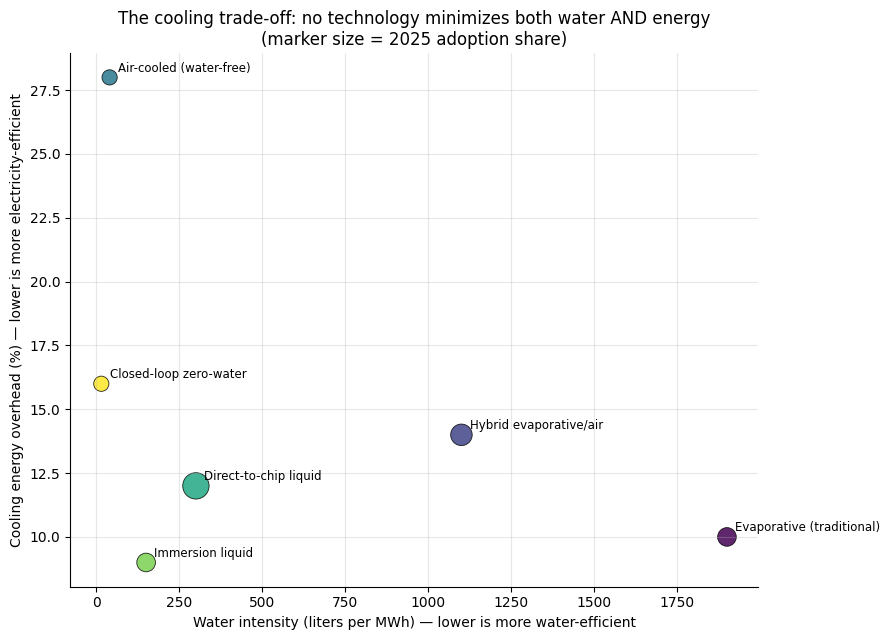

In [14]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(cooling_tech["water_intensity_l_per_mwh"], cooling_tech["cooling_energy_overhead_pct"],
                 s=cooling_tech["adoption_2025_pct_of_new_builds"] * 12, c=range(len(cooling_tech)),
                 cmap="viridis", edgecolor="black", linewidth=0.6, alpha=0.85)

for _, row in cooling_tech.iterrows():
    ax.annotate(row["cooling_type"], (row["water_intensity_l_per_mwh"], row["cooling_energy_overhead_pct"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8.5)

ax.set_xlabel("Water intensity (liters per MWh) — lower is more water-efficient")
ax.set_ylabel("Cooling energy overhead (%) — lower is more electricity-efficient")
ax.set_title("The cooling trade-off: no technology minimizes both water AND energy\n(marker size = 2025 adoption share)")
plt.tight_layout()
plt.show()


In [15]:
# Identify the PARETO FRONIER: technologies where no OTHER technology is
# simultaneously better on both dimensions -- a genuinely useful, slightly
# more advanced NumPy technique (nested boolean comparison across all pairs)
water = cooling_tech["water_intensity_l_per_mwh"].values
energy = cooling_tech["cooling_energy_overhead_pct"].values

is_dominated = np.zeros(len(cooling_tech), dtype=bool)
for i in range(len(cooling_tech)):
    # technology i is DOMINATED if some other technology j is better (lower)
    # on BOTH water AND energy simultaneously
    dominated_by_others = (water < water[i]) & (energy < energy[i])
    is_dominated[i] = dominated_by_others.any()

cooling_tech["on_efficient_frontier"] = ~is_dominated
cooling_tech[["cooling_type", "water_intensity_l_per_mwh", "cooling_energy_overhead_pct", "on_efficient_frontier"]]


,cooling_type,water_intensity_l_per_mwh,cooling_energy_overhead_pct,on_efficient_frontier
0,Evaporative (traditional),1900,10,False
1,Hybrid evaporative/air,1100,14,False
2,Air-cooled (water-free),40,28,False
3,Direct-to-chip liquid,300,12,False
4,Immersion liquid,150,9,True
5,Closed-loop zero-water,15,16,True


The technologies **on the frontier** represent genuine trade-off choices — you can't say one is simply "better," only that each makes a different bet about which resource is scarcer *in that location*. This is exactly why the cited sources note some hyperscalers choose *different* cooling approaches in different regions depending on local water stress vs. grid capacity.

## 5. pandas: Regional Trends, Hyperscaler Capex, and Component Structure


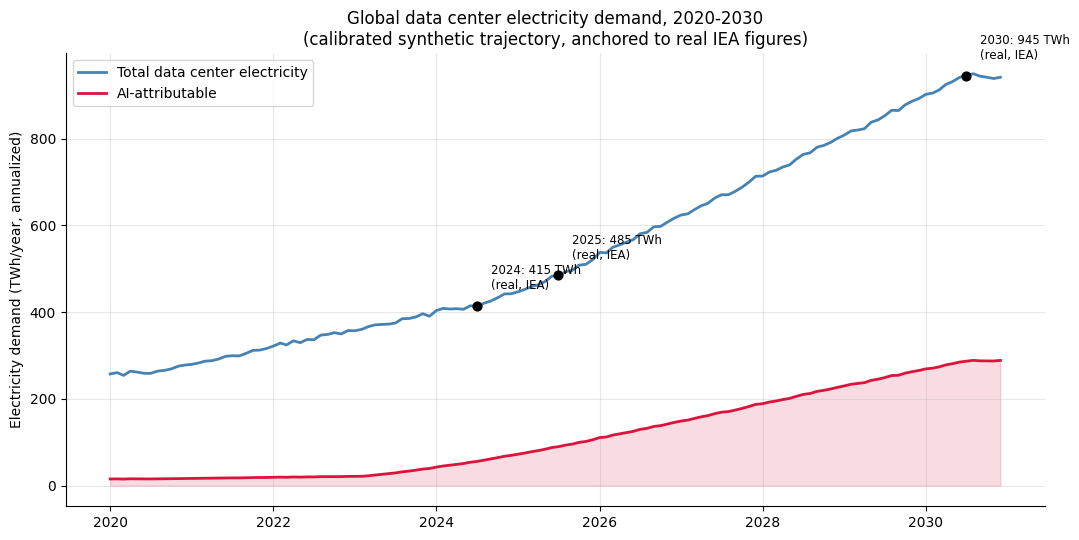

In [16]:
demand_ts = demand.set_index("month")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(demand_ts.index, demand_ts["total_dc_electricity_twh_annualized"], color="steelblue", lw=2, label="Total data center electricity")
ax.plot(demand_ts.index, demand_ts["ai_dc_electricity_twh_annualized"], color="crimson", lw=2, label="AI-attributable")
ax.fill_between(demand_ts.index, 0, demand_ts["ai_dc_electricity_twh_annualized"], color="crimson", alpha=0.15)

for _, row in real_global_demand_anchors.iterrows():
    ax.scatter([pd.Timestamp(f"{row['year']}-06-30")], [row["global_dc_electricity_twh"]],
               color="black", zorder=5, s=40)
    ax.annotate(f"{row['year']}: {row['global_dc_electricity_twh']} TWh\n(real, IEA)",
                xy=(pd.Timestamp(f"{row['year']}-06-30"), row["global_dc_electricity_twh"]),
                xytext=(10, 12), textcoords="offset points", fontsize=8.5)

ax.set_ylabel("Electricity demand (TWh/year, annualized)")
ax.set_title("Global data center electricity demand, 2020-2030\n(calibrated synthetic trajectory, anchored to real IEA figures)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


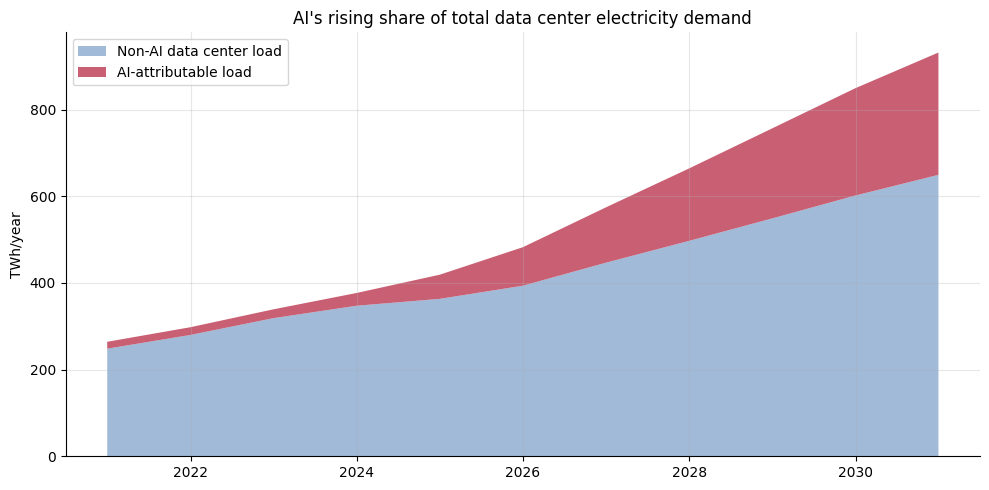

In [17]:
# resample('YE') + a stacked area view of AI vs non-AI, in ANNUAL terms --
# a cleaner view of the share shift than the noisy monthly series
annual = demand_ts.resample("YE").mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(annual.index, annual["non_ai_dc_electricity_twh_annualized"], annual["ai_dc_electricity_twh_annualized"],
             labels=["Non-AI data center load", "AI-attributable load"], colors=["#8faed1", "#c0435a"], alpha=0.85)
ax.set_ylabel("TWh/year"); ax.set_title("AI's rising share of total data center electricity demand")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


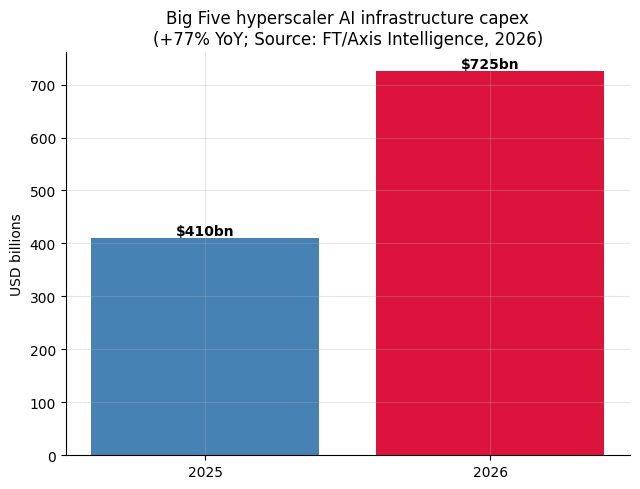

In [18]:
# Hyperscaler capex: REAL data, just two points, but the growth rate is the story
fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(real_hyperscaler_capex["year"].astype(str), real_hyperscaler_capex["big_five_ai_capex_usd_bn"],
               color=["steelblue", "crimson"])
for b in bars:
    ax.annotate(f"${b.get_height():.0f}bn", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("USD billions")
ax.set_title("Big Five hyperscaler AI infrastructure capex\n(+77% YoY; Source: FT/Axis Intelligence, 2026)")
plt.tight_layout()
plt.show()


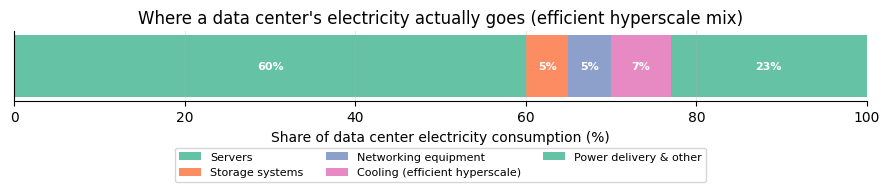

In [19]:
# groupby-style component breakdown, visualized as a horizontal stacked bar --
# using the REAL IEA component-share data
fig, ax = plt.subplots(figsize=(9, 3))
left = 0
colors = sns.color_palette("Set2", len(real_component_breakdown) - 1)   # -1: we'll only plot the "typical" mix
typical_mix = real_component_breakdown.iloc[[0, 1, 2, 3]].copy()   # servers, storage, network, efficient cooling
typical_mix.loc[len(typical_mix)] = ["Power delivery & other", 100 - typical_mix["share_of_electricity_pct"].sum(), "remainder"]

for i, row in typical_mix.iterrows():
    ax.barh(0, row["share_of_electricity_pct"], left=left, color=colors[i % len(colors)], label=row["component"])
    if row["share_of_electricity_pct"] > 4:
        ax.text(left + row["share_of_electricity_pct"]/2, 0, f"{row['share_of_electricity_pct']:.0f}%",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    left += row["share_of_electricity_pct"]

ax.set_yticks([]); ax.set_xlim(0, 100)
ax.set_xlabel("Share of data center electricity consumption (%)")
ax.set_title("Where a data center's electricity actually goes (efficient hyperscale mix)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.6), ncols=3, fontsize=8)
plt.tight_layout()
plt.show()


## 6. Geographic View: Where the Strain Concentrates


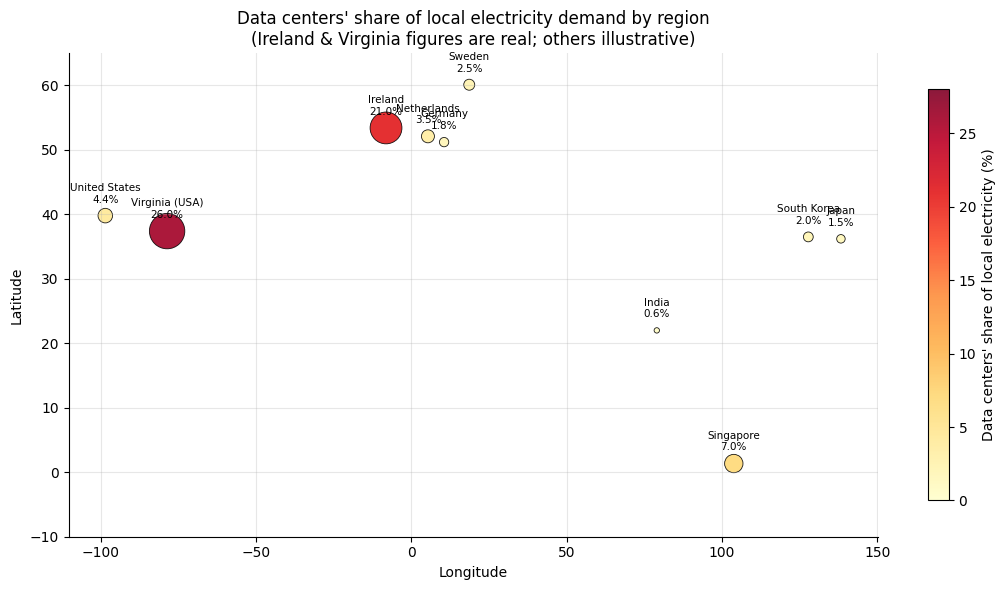

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(region_data["lon"], region_data["lat"], s=region_data["data_center_share_of_electricity_pct"] * 25,
                 c=region_data["data_center_share_of_electricity_pct"], cmap="YlOrRd",
                 edgecolor="black", linewidth=0.6, alpha=0.9, vmin=0, vmax=28)
for _, row in region_data.iterrows():
    ax.annotate(f"{row['region']}\n{row['data_center_share_of_electricity_pct']:.1f}%",
                (row["lon"], row["lat"]), fontsize=7.5, ha="center", va="bottom", xytext=(0, 8),
                textcoords="offset points")

cbar = fig.colorbar(sc, ax=ax, shrink=0.85); cbar.set_label("Data centers' share of local electricity (%)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_ylim(-10, 65)
ax.set_title("Data centers' share of local electricity demand by region\n(Ireland & Virginia figures are real; others illustrative)")
plt.tight_layout()
plt.show()


## 7. One-Page Dashboard


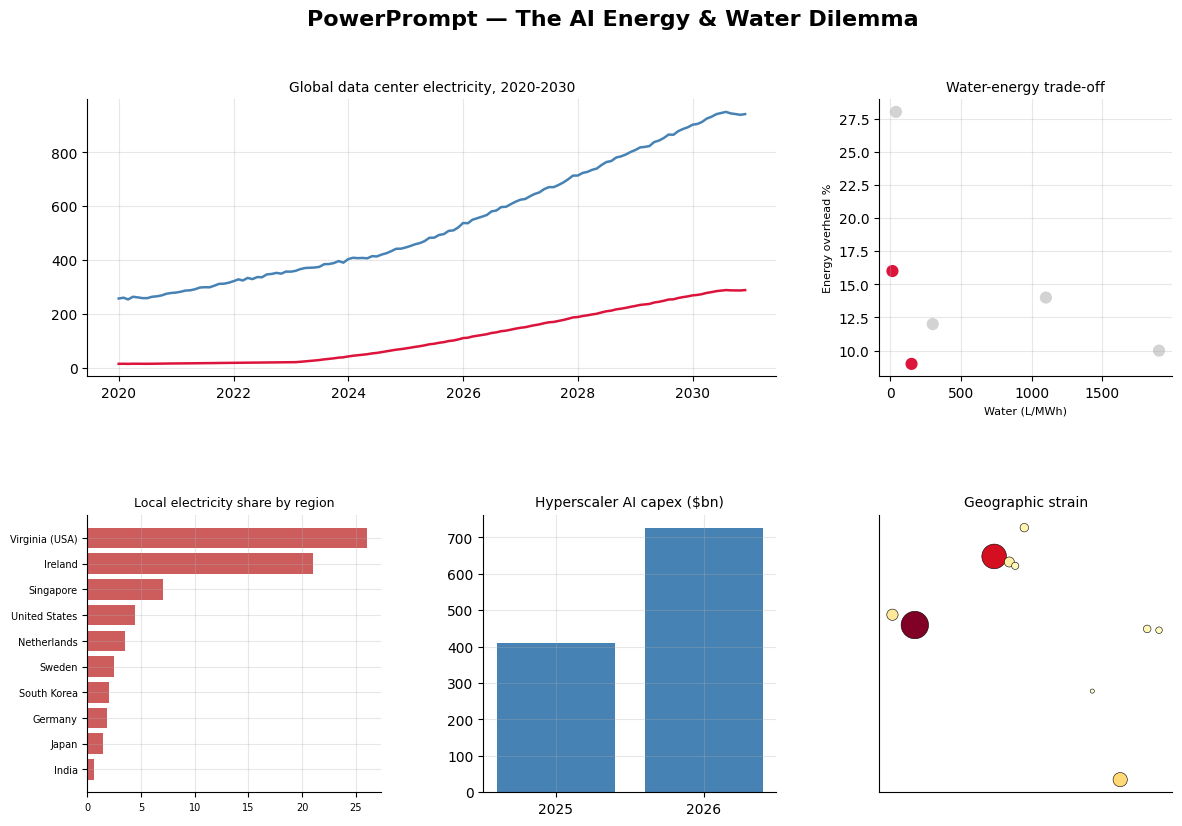

In [21]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(demand_ts.index, demand_ts["total_dc_electricity_twh_annualized"], color="steelblue", lw=1.8)
ax1.plot(demand_ts.index, demand_ts["ai_dc_electricity_twh_annualized"], color="crimson", lw=1.8)
ax1.set_title("Global data center electricity, 2020-2030", fontsize=10)

ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(cooling_tech["water_intensity_l_per_mwh"], cooling_tech["cooling_energy_overhead_pct"],
            c=cooling_tech["on_efficient_frontier"].map({True: "crimson", False: "lightgray"}), s=60)
ax2.set_title("Water-energy trade-off", fontsize=10)
ax2.set_xlabel("Water (L/MWh)", fontsize=8); ax2.set_ylabel("Energy overhead %", fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
order_top6 = region_data.sort_values("data_center_share_of_electricity_pct", ascending=True)
ax3.barh(order_top6["region"], order_top6["data_center_share_of_electricity_pct"], color="indianred")
ax3.set_title("Local electricity share by region", fontsize=9)
ax3.tick_params(labelsize=7)

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(real_hyperscaler_capex["year"].astype(str), real_hyperscaler_capex["big_five_ai_capex_usd_bn"], color="steelblue")
ax4.set_title("Hyperscaler AI capex ($bn)", fontsize=10)

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(region_data["lon"], region_data["lat"], s=region_data["data_center_share_of_electricity_pct"]*15,
                   c=region_data["data_center_share_of_electricity_pct"], cmap="YlOrRd", edgecolor="black", linewidth=0.4)
ax5.set_xticks([]); ax5.set_yticks([]); ax5.set_title("Geographic strain", fontsize=10)

fig.suptitle("PowerPrompt — The AI Energy & Water Dilemma", fontsize=16, fontweight="bold")
plt.show()


## 8. Wrap-up: What This Data Does and Doesn't Settle

### What we built
Anchored to a set of **real, cited IEA/industry figures**, we built a
calibrated synthetic pipeline to explore the AI energy/water dilemma
quantitatively:

- **NumPy**: broadcasting a water-intensity vector against AI electricity
  demand to compute footprints under six cooling technologies, boolean
  masking for grid-strain thresholds, sorting/ranking regions, and a
  from-scratch **Pareto-frontier computation** identifying which cooling
  technologies represent genuine trade-offs vs. which are simply dominated
- **pandas**: a decade-long monthly time series resampled to annual,
  stacked-area decomposition of AI vs. non-AI load, and structured
  real-data tables for capex and component breakdown
- **Visualization**: an annotated trajectory tied to real IEA anchor
  points, a stacked-area AI-share chart, the central water-vs-energy
  trade-off scatter, a geographic strain map, and a one-page dashboard

### The core finding, restated
The scatter plot in Section 4 **is** the dilemma: every cooling technology
sits somewhere on a trade-off between water and electricity, and the
"efficient frontier" computation shows there's no free lunch among current
approaches — only different bets about which resource is scarcer in a
given location. That's not a data artifact; it's the real physical/
engineering constraint the cited sources describe.

### Important caveats
- The **monthly trajectory, regional table (beyond Ireland/Virginia), and
  cooling-technology numbers are synthetic**, calibrated to be consistent
  with — but not identical to — the real published figures. Treat exact
  values as illustrative, not citable statistics.
- **Per-query or per-model energy/water estimates are highly contested** in
  the current literature (methodologies vary widely) and were deliberately
  **not** included here; the notebook sticks to aggregate, well-sourced
  figures instead.
- This notebook does not take a position on whether AI's resource growth is
  justified by its benefits — that's a genuine, actively debated question
  involving economic value, climate policy, and local community impact
  that reasonable people weigh differently.

### Sources cited in this notebook
- IEA, *Key Questions on Energy and AI*, 2026
- IEA, *Energy and AI — Energy Demand from AI*, 2025
- Environmental Law Institute, *Data Centers and Water Fact Sheet*, Jan 2026
- Axis Intelligence, *AI Data Center Statistics 2026*, 2026 (FT earnings-guidance compilation)
- ScienceDirect, *"The carbon and water footprints of data centers..."*, Dec 2025
- MOST Policy Initiative, science note on data center cooling trade-offs, Apr 2026
- AIMultiple, *AI Energy Consumption Statistics*, 2026

### Where to go next
- Replace the synthetic regional table with real utility-filing or grid-
  operator interconnection-queue data for a specific region you care about.
- Extend the Pareto-frontier analysis to include carbon intensity of the
  local grid as a third dimension (water, energy, and carbon all trade off
  differently depending on the region's power mix).
- Track the IEA's *Energy and AI* report annually — it is explicitly
  updated as better bottom-up data becomes available, and several cited
  sources note current estimates remain wide-ranging.
